# 🏦 Loan Prediction - Machine Learning Pipeline
**Dataset:** 4269 records | 12 features | Binary Classification (Approved / Rejected)

---
### Workflow
1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Model Training (Multiple Algorithms)
5. Evaluation & Comparison
6. Save Best Model

## 1. 📦 Install & Import Libraries

In [4]:
# Install required libraries (uncomment if needed)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('✅ All libraries imported successfully!')

## 2. 📂 Load Dataset

In [5]:
df = pd.read_csv('data.csv')

# Clean column names (strip leading/trailing spaces)
df.columns = df.columns.str.strip()

print(f'📊 Dataset Shape: {df.shape}')
print(f'📌 Columns: {list(df.columns)}')
df.head()

📊 Dataset Shape: (4269, 13)
📌 Columns: ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
print('=== Dataset Info ===')
df.info()
print('\n=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB

=== Basi

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\n✅ Total missing values: {df.isnull().sum().sum()}')

print('\n=== Target Variable Distribution ===')
print(df['loan_status'].value_counts())
print(f'\nClass Balance: {df["loan_status"].value_counts(normalize=True).round(3).to_dict()}')

=== Missing Values ===
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

✅ Total missing values: 0

=== Target Variable Distribution ===
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

Class Balance: {' Approved': 0.622, ' Rejected': 0.378}


## 3. 📊 Exploratory Data Analysis (EDA)

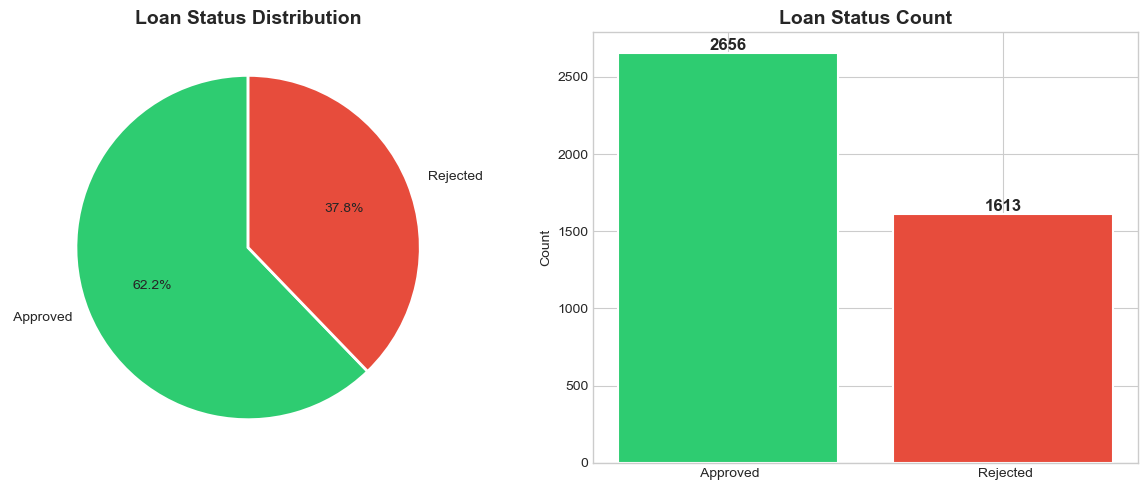

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target distribution - pie chart
counts = df['loan_status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Loan Status Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

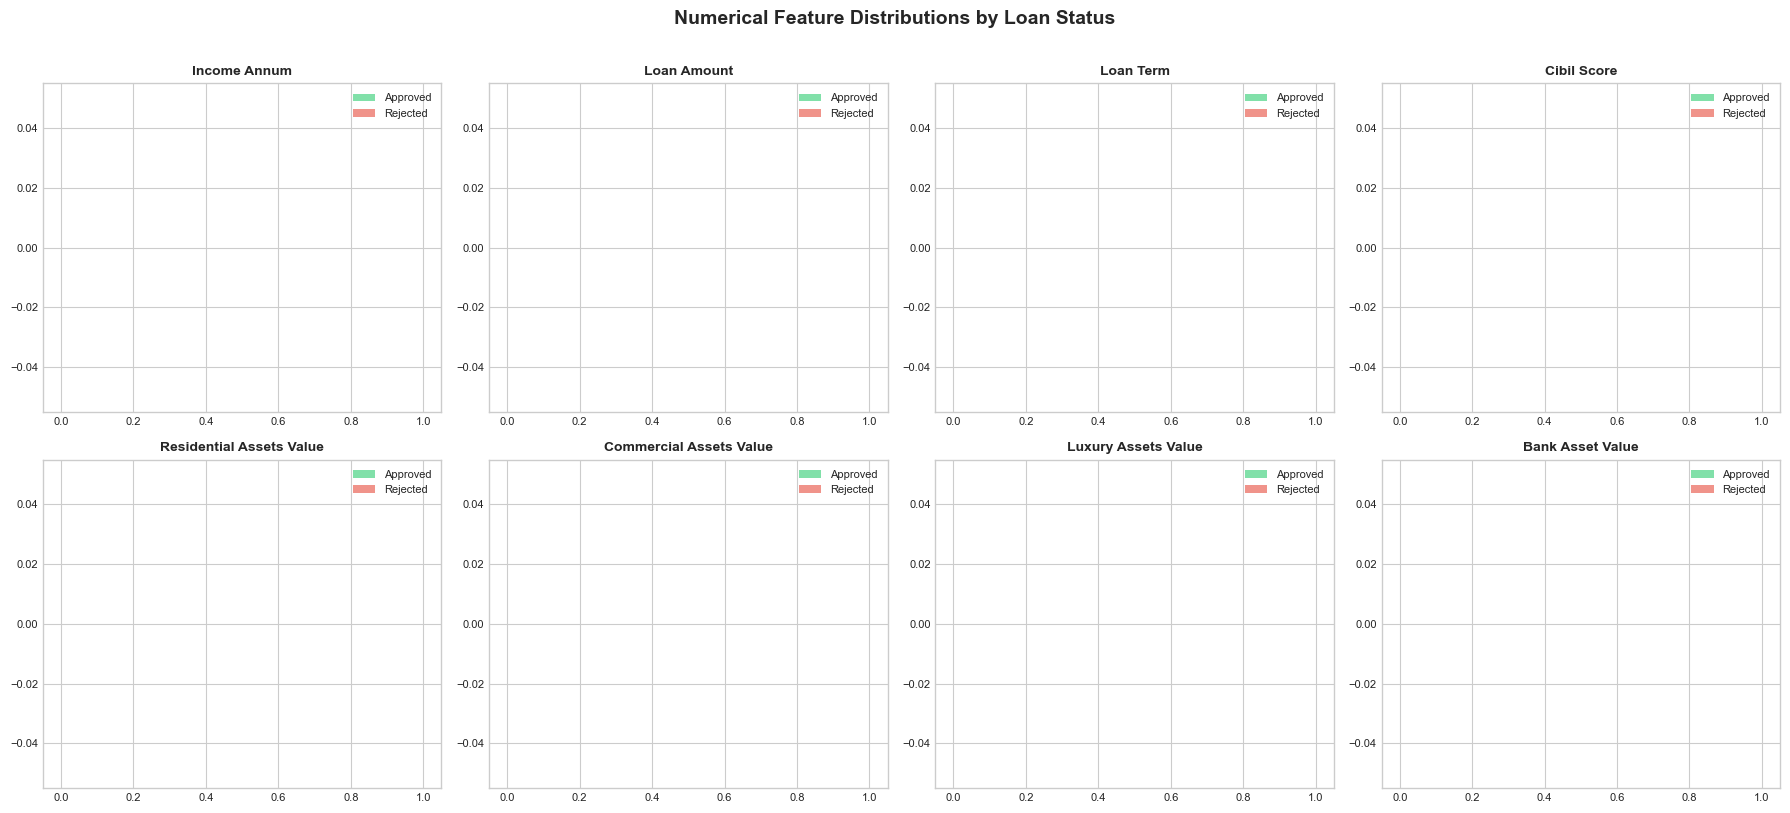

In [9]:
# Numerical features distribution
num_cols = ['income_annum', 'loan_amount', 'loan_term', 'cibil_score',
            'residential_assets_value', 'commercial_assets_value',
            'luxury_assets_value', 'bank_asset_value']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for status, color in zip(['Approved', 'Rejected'], ['#2ecc71', '#e74c3c']):
        axes[i].hist(df[df['loan_status'] == status][col], bins=30,
                     alpha=0.6, label=status, color=color, edgecolor='none')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Numerical Feature Distributions by Loan Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

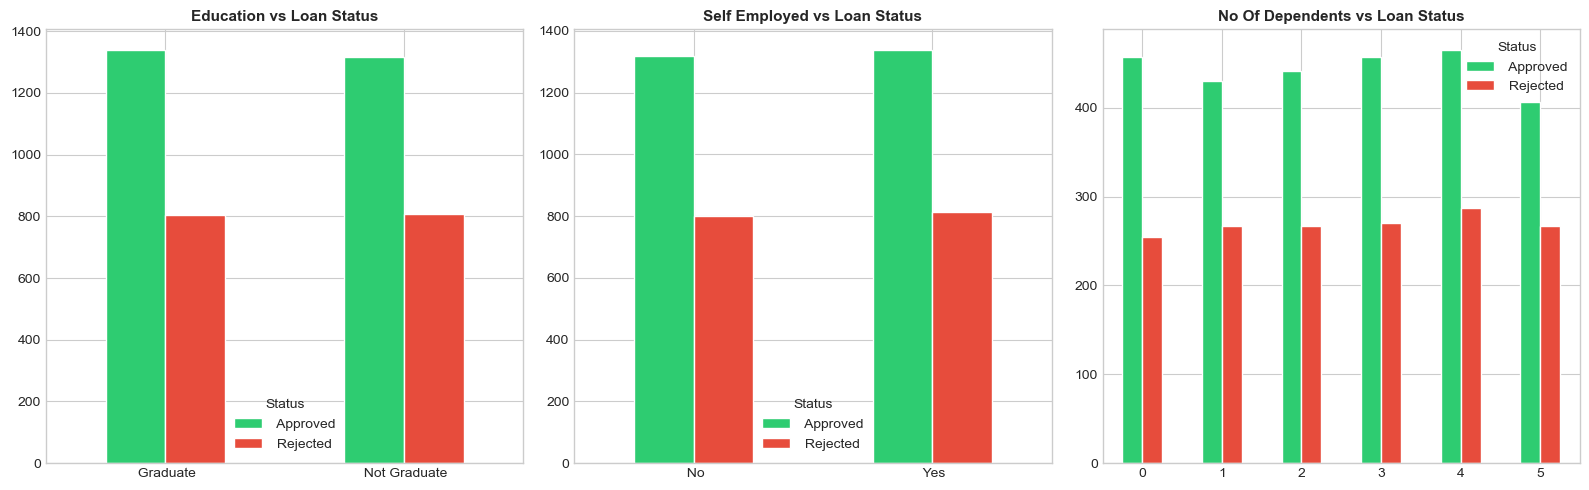

In [10]:
# Categorical feature analysis
cat_cols = ['education', 'self_employed', 'no_of_dependents']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['loan_status'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1)
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Loan Status',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Status')

plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

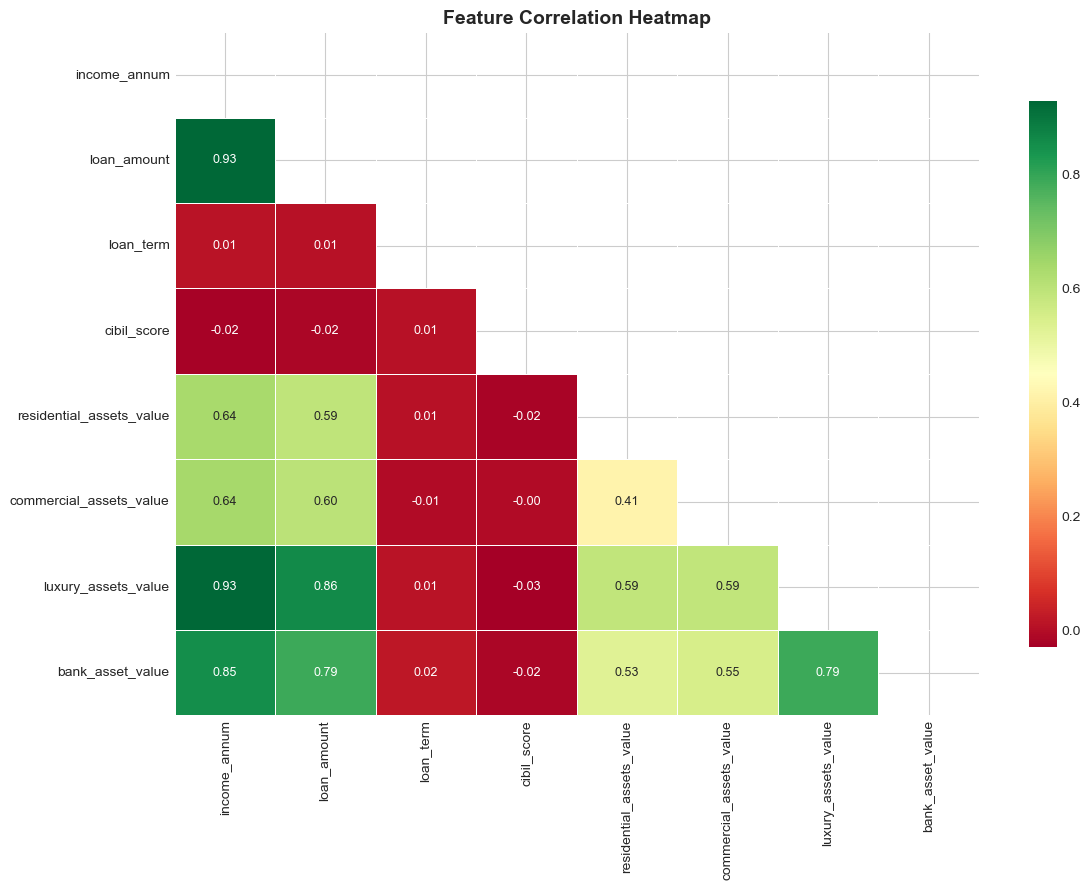

In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', mask=mask,
            linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 900x500 with 0 Axes>

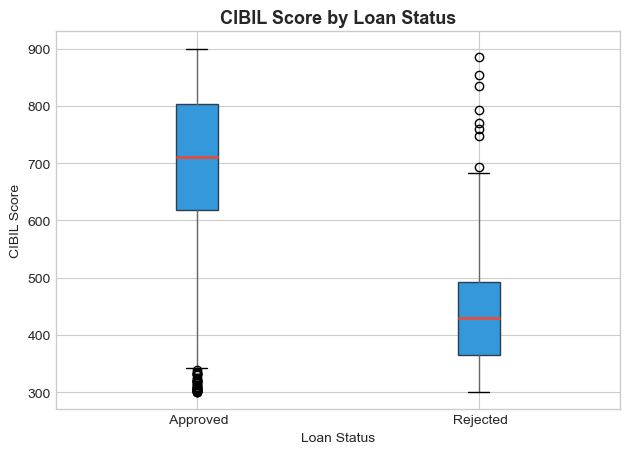

In [12]:
# CIBIL score boxplot - very important feature
plt.figure(figsize=(9, 5))
df.boxplot(column='cibil_score', by='loan_status',
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='#2c3e50'),
           medianprops=dict(color='#e74c3c', linewidth=2))
plt.title('CIBIL Score by Loan Status', fontsize=13, fontweight='bold')
plt.suptitle('')
plt.xlabel('Loan Status')
plt.ylabel('CIBIL Score')
plt.tight_layout()
plt.savefig('cibil_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 🔧 Preprocessing & Feature Engineering

In [13]:
df_model = df.copy()

# Drop ID column
df_model.drop('loan_id', axis=1, inplace=True)

# Encode categorical columns
le_edu = LabelEncoder()
le_emp = LabelEncoder()
le_target = LabelEncoder()

df_model['education'] = le_edu.fit_transform(df_model['education'])          # Graduate=0, Not Graduate=1
df_model['self_employed'] = le_emp.fit_transform(df_model['self_employed'])  # No=0, Yes=1
df_model['loan_status'] = le_target.fit_transform(df_model['loan_status'])   # Approved=0, Rejected=1

print('Label Encoding:')
print(f'  education classes: {le_edu.classes_}')
print(f'  self_employed classes: {le_emp.classes_}')
print(f'  loan_status classes: {le_target.classes_}')

# Save encoders
joblib.dump(le_edu, 'le_education.pkl')
joblib.dump(le_emp, 'le_self_employed.pkl')
joblib.dump(le_target, 'le_loan_status.pkl')

df_model.head()

Label Encoding:
  education classes: [' Graduate' ' Not Graduate']
  self_employed classes: [' No' ' Yes']
  loan_status classes: [' Approved' ' Rejected']


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [14]:
# Feature Engineering
df_model['total_assets'] = (df_model['residential_assets_value'] +
                             df_model['commercial_assets_value'] +
                             df_model['luxury_assets_value'] +
                             df_model['bank_asset_value'])

df_model['loan_to_income_ratio'] = df_model['loan_amount'] / (df_model['income_annum'] + 1)
df_model['asset_to_loan_ratio'] = df_model['total_assets'] / (df_model['loan_amount'] + 1)
df_model['income_per_dependent'] = df_model['income_annum'] / (df_model['no_of_dependents'] + 1)

print('✅ New features added:')
print('  - total_assets')
print('  - loan_to_income_ratio')
print('  - asset_to_loan_ratio')
print('  - income_per_dependent')
print(f'\nFinal shape: {df_model.shape}')

✅ New features added:
  - total_assets
  - loan_to_income_ratio
  - asset_to_loan_ratio
  - income_per_dependent

Final shape: (4269, 16)


In [15]:
# Train-test split
X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler and feature names
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print(f'✅ Train size: {X_train.shape}')
print(f'✅ Test size:  {X_test.shape}')
print(f'\nClass distribution in train:')
print(pd.Series(y_train).value_counts())

✅ Train size: (3415, 15)
✅ Test size:  (854, 15)

Class distribution in train:
loan_status
0    2125
1    1290
Name: count, dtype: int64


## 5. 🤖 Model Training & Comparison

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=150, max_depth=8,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                       max_depth=4, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=4,
                                          use_label_encoder=False, eval_metric='logloss',
                                          random_state=42),
    'SVM':                 SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Training models...')
print('-' * 65)
print(f'{"Model":<25} {"CV Acc":>10} {"Test Acc":>10} {"ROC-AUC":>10}')
print('-' * 65)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    test_acc = accuracy_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model': model, 'cv_acc': cv_scores.mean(),
        'test_acc': test_acc, 'roc_auc': roc_auc,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    print(f'{name:<25} {cv_scores.mean():>10.4f} {test_acc:>10.4f} {roc_auc:>10.4f}')

print('-' * 65)

Training models...
-----------------------------------------------------------------
Model                         CV Acc   Test Acc    ROC-AUC
-----------------------------------------------------------------
Logistic Regression           0.9089     0.9169     0.9746
Decision Tree                 1.0000     1.0000     1.0000
Random Forest                 0.9980     1.0000     1.0000
Gradient Boosting             1.0000     1.0000     1.0000
XGBoost                       0.9980     0.9988     1.0000
SVM                           0.9403     0.9461     0.9856
-----------------------------------------------------------------


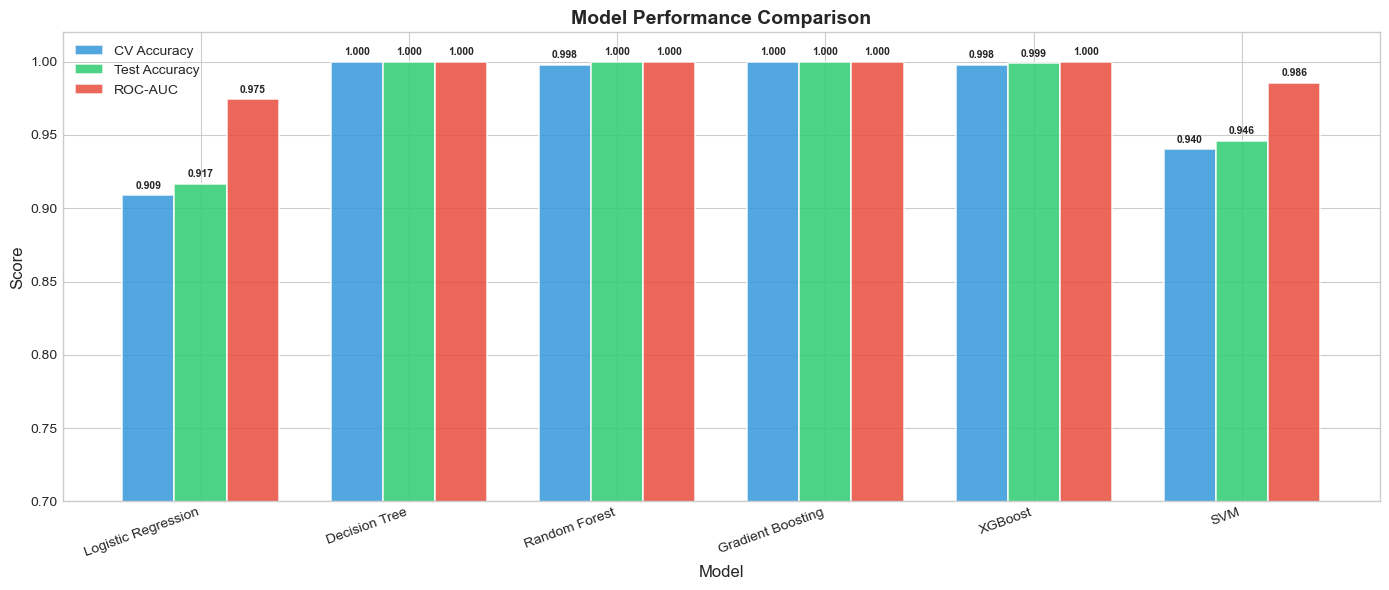

In [17]:
# Model comparison chart
metrics = ['cv_acc', 'test_acc', 'roc_auc']
labels  = ['CV Accuracy', 'Test Accuracy', 'ROC-AUC']
model_names = list(results.keys())

x = np.arange(len(model_names))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, label, color) in enumerate(zip(metrics, labels, colors)):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width, label=label, color=color,
                  edgecolor='white', linewidth=1.2, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(0.7, 1.02)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 🏆 Best Model Deep-Dive

In [18]:
# Identify best model by ROC-AUC
best_name = max(results, key=lambda m: results[m]['roc_auc'])
best = results[best_name]
print(f'🏆 Best Model: {best_name}')
print(f'   Test Accuracy: {best["test_acc"]:.4f}')
print(f'   ROC-AUC:       {best["roc_auc"]:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, best['y_pred'],
      target_names=le_target.classes_))

🏆 Best Model: Decision Tree
   Test Accuracy: 1.0000
   ROC-AUC:       1.0000

Classification Report:
              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00       531
    Rejected       1.00      1.00      1.00       323

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



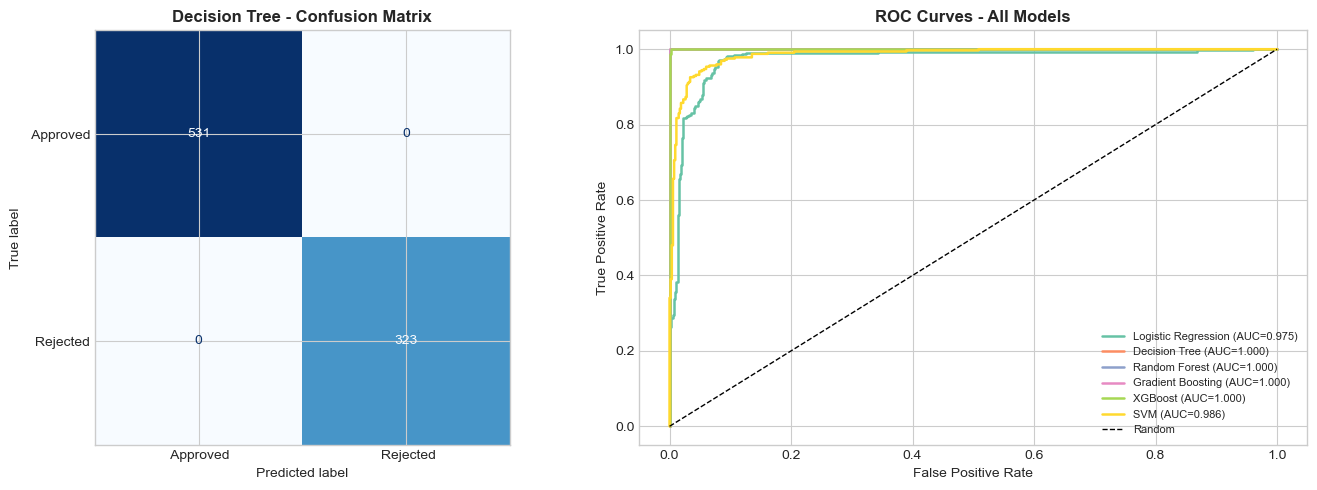

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_name} - Confusion Matrix', fontsize=12, fontweight='bold')

# ROC Curves for all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={res["roc_auc"]:.3f})', linewidth=1.8)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves - All Models', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

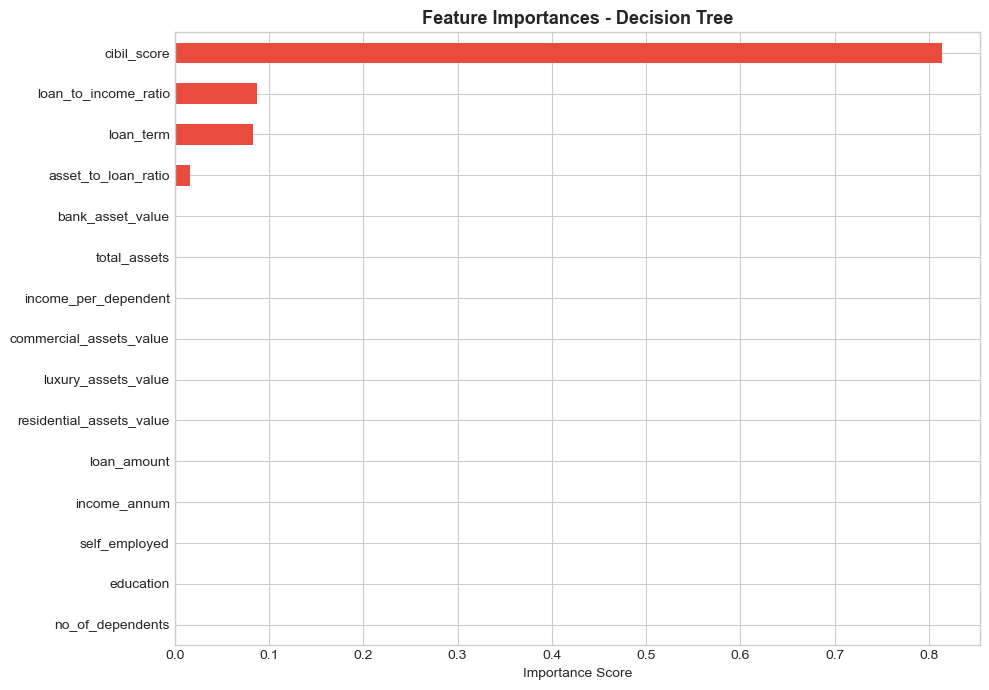

Top 5 most important features:
cibil_score             0.813386
loan_to_income_ratio    0.087828
loan_term               0.082723
asset_to_loan_ratio     0.016062
no_of_dependents        0.000000
dtype: float64


In [20]:
# Feature Importance (for tree-based models)
if hasattr(best['model'], 'feature_importances_'):
    feat_imp = pd.Series(best['model'].feature_importances_, index=X.columns)
    feat_imp = feat_imp.sort_values(ascending=True)

    plt.figure(figsize=(10, 7))
    colors_bar = ['#e74c3c' if x > feat_imp.quantile(0.75) else '#3498db' for x in feat_imp]
    feat_imp.plot(kind='barh', color=colors_bar, edgecolor='none')
    plt.title(f'Feature Importances - {best_name}', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Top 5 most important features:')
    print(feat_imp.sort_values(ascending=False).head())
else:
    print(f'{best_name} does not have feature_importances_. Use Logistic Regression coefficients or SHAP for interpretation.')

## 7. 💾 Save Model

In [21]:
# Save the best model
joblib.dump(best['model'], 'loan_model.pkl')
print(f'✅ Model saved as: loan_model.pkl')
print(f'✅ Scaler saved as: scaler.pkl')
print(f'✅ Encoders saved as: le_education.pkl, le_self_employed.pkl, le_loan_status.pkl')
print(f'✅ Feature names saved as: feature_names.pkl')
print(f'\n🏆 Best model: {best_name}')
print(f'   ROC-AUC: {best["roc_auc"]:.4f}  |  Test Accuracy: {best["test_acc"]:.4f}')

✅ Model saved as: loan_model.pkl
✅ Scaler saved as: scaler.pkl
✅ Encoders saved as: le_education.pkl, le_self_employed.pkl, le_loan_status.pkl
✅ Feature names saved as: feature_names.pkl

🏆 Best model: Decision Tree
   ROC-AUC: 1.0000  |  Test Accuracy: 1.0000


In [22]:
# Quick inference test
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
pred = best['model'].predict(sample_scaled)
prob = best['model'].predict_proba(sample_scaled)

print('=== Inference Test ===')
print(f'Input features:\n{sample.to_dict(orient="records")[0]}')
print(f'\nPrediction: {le_target.inverse_transform(pred)[0]}')
print(f'Probabilities -> Approved: {prob[0][0]:.3f} | Rejected: {prob[0][1]:.3f}')
print(f'Actual label: {le_target.inverse_transform([y_test.iloc[0]])[0]}')

=== Inference Test ===
Input features:
{'no_of_dependents': 3, 'education': 0, 'self_employed': 0, 'income_annum': 8000000, 'loan_amount': 26200000, 'loan_term': 16, 'cibil_score': 890, 'residential_assets_value': 15800000, 'commercial_assets_value': 4300000, 'luxury_assets_value': 25000000, 'bank_asset_value': 4000000, 'total_assets': 49100000, 'loan_to_income_ratio': 3.2749995906250513, 'asset_to_loan_ratio': 1.8740457299982545, 'income_per_dependent': 2000000.0}

Prediction:  Approved
Probabilities -> Approved: 1.000 | Rejected: 0.000
Actual label:  Approved
